# Preparación: imagen generada con IA

Genera una imagen con un generador de IA gratuito (ej. Bing Image Creator).
**Requisito:** dimensiones 1024x1024x3, no usar imágenes predefinidas de la plataforma.

In [1]:
# numpy: manejo de la imagen como matriz (arreglo N-dimensional) y toda la
#        indexación (recortes, reflexiones, reordenar canales).
# matplotlib.pyplot: mostrar y guardar (savefig) las imágenes resultantes.
# PIL.Image: leer archivos de imagen (.png/.tif) y convertir entre modos
#            de color (RGB, L = escala de grises).
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# sys.path.append("..") permite importar utils.py, que está un nivel arriba
# (en la raíz del proyecto), desde dentro de la carpeta notebooks/.
import sys
sys.path.append("..")
from utils import to_uint8, gamma_transform, log_transform, piecewise_linear, gray_level_slicing


## Prompt e imagen usada

"genera una imagen con el personaje que te pasé pero que esté jugando voleibol con otras personas, la imagen tiene que tener dimensiones 1024x1024x3"

![Cinnamoroll IA](../images/cinnamorroll.png)

imagen usada: (1254, 1254, 3) uint8


(np.float64(-0.5), np.float64(1253.5), np.float64(1253.5), np.float64(-0.5))

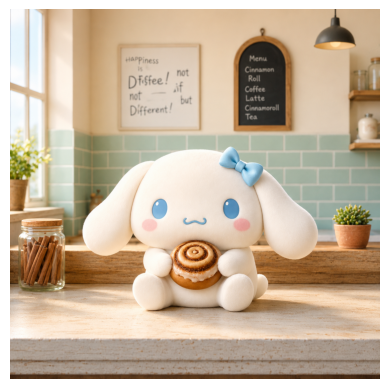

In [2]:
# Image.open + convert("RGB"): abre el archivo y fuerza 3 canales de color.
# np.array(...): convierte la imagen de PIL a un arreglo numpy (alto, ancho, canales).
img_path = "../images/cinnamorroll.png"
img_original = np.array(Image.open(img_path).convert("RGB"))
print("imagen usada:", img_original.shape, img_original.dtype)

# plt.imshow: muestra el arreglo numpy como imagen en el notebook.
plt.imshow(img_original)
plt.axis("off")


## Redimensionar a 1024x1024x3

La imagen ya es cuadrada, así que el resize no la distorsiona.

final: (1024, 1024, 3) uint8


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

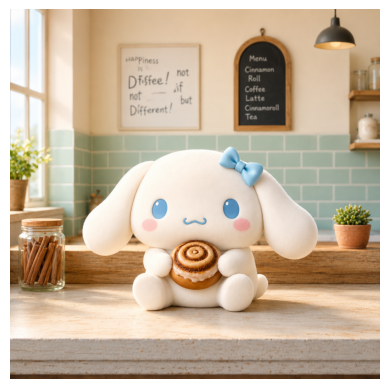

In [3]:
# El enunciado pide 1024x1024x3. Como la imagen ya es cuadrada (1254x1254),
# un resize no la deforma (misma relación de aspecto 1:1 antes y después).
# Image.fromarray: convierte el arreglo numpy de vuelta a imagen de PIL para
# poder usar su método .resize().
img = np.array(Image.fromarray(img_original).resize((1024, 1024)))
print("final:", img.shape, img.dtype)

# Se guarda en disco (Image.fromarray(...).save) para que el resto de
# notebooks del taller la carguen ya lista, sin repetir el resize.
Image.fromarray(img).save("../images/cinnamorroll_1024.png")

plt.imshow(img)
plt.axis("off")
